# Explore the bee microbiome use case

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib import colors as mcolors


import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str((Path.cwd() / "bin").resolve()))
sys.path.insert(0, str(Path.cwd().resolve()))

from helpers import (
    load_dfs,
    compute_print_stats,
    explore_species_level_clusters_all,
    compute_taxo_classification_summary,
    get_all_taxo_levels,
    get_bakta_annot_df,
    get_kegg_path_df,
    get_relative_abund_taxo_levels,
    print_stats,
)

In [2]:
data_dp = Path("../data/use-cases/bee-microbiome/")
data_dp.exists()

data_dp_2 = Path("../data/bee-use-case/")
data_dp_2.exists()

result_dp = Path("../results/bee-use-case/")
result_dp.exists()

rep_fn = "reps_bee.tsv"

metadata_df, reps_df, coverage_df = load_dfs(data_dp_2, result_dp, rep_fn)

In [3]:
expert_evaluation_fp = data_dp / "expert_evaluation.xlsx"
df_expert = pd.read_excel(expert_evaluation_fp)

# Quick overview
print(f"Rows: {len(df_expert)}")
print(f"Columns: {df_expert.shape[1]}")

Rows: 48
Columns: 22


In [4]:
sample_order = [
    "C1", "C2", "C3",
    "P1", "P2", "P3",
    "T1", "T2", "T3",
    "TP1", "TP2", "TP3",
    "N1", "N2", "N3",
    "NP1", "NP2", "NP3",
    "NT1", "NT2", "NT3",
]
metadata_df["Replicate"] = metadata_df["Replicate"].astype(str).str.replace(r"\s+Replicate", "", regex=True)

# Quality

In [ ]:
read_numbers = {
    "SRR24759596": 28.0,
    "SRR24759597": 18.1,
    "SRR24759598": 43.9,
    "SRR24759599": 55.3,
    "SRR24759600": 35.8,
    "SRR24759601": 11.9,
    "SRR24759602": 18.6,
    "SRR24759603": 32.0,
    "SRR24759604": 42.5,
    "SRR24759605": 48.7,
    "SRR24759606": 45.6,
    "SRR24759607": 7.8,
    "SRR24759608": 44.7,
    "SRR24759609": 45.8,
    "SRR24759610": 48.0,
    "SRR24759611": 42.1,
    "SRR24759612": 32.6,
    "SRR24759613": 42.3,
    "SRR24759614": 40.4,
    "SRR24759615": 43.6,
    "SRR24759616": 42.8
}
read_numbers_df = pd.DataFrame.from_dict(read_numbers, orient="index", columns=["Read numbers (M)"])
print_stats(read_numbers_df.describe())

In [5]:
print(f"Total number of MAGs: {reps_df['Cluster members'].sum()}")
print(f"Total number of species-level clusters: {reps_df.shape[0]}")

Total number of MAGs: 161
Total number of species-level clusters: 38


In [6]:
explore_species_level_clusters_all(reps_df)

Species-level clusters with no contamination threshold
Total number: 38.0
Cluster members: 4.24 ± 4.61, Median: 2.00, IQR: 1.00-6.00, Range: 1.00-17.00
Contamination: 2.47 ± 3.60, Median: 1.26, IQR: 0.43-2.44, Range: 0.05-18.57
Completeness: 90.55 ± 9.62, Median: 94.40, IQR: 81.35-99.75, Range: 75.00-100.00
Total length: 2.70 ± 1.12, Median: 2.45, IQR: 1.92-3.29, Range: 1.05-5.44

Species-level clusters with contamination < 5%
Total number: 31.0
Cluster members: 4.90 ± 4.87, Median: 3.00, IQR: 1.00-7.50, Range: 1.00-17.00
Contamination: 1.07 ± 0.89, Median: 0.91, IQR: 0.30-1.66, Range: 0.05-3.09
Completeness: 93.09 ± 8.66, Median: 98.40, IQR: 86.85-99.95, Range: 75.00-100.00
Total length: 2.70 ± 1.18, Median: 2.51, IQR: 1.71-3.34, Range: 1.05-5.44

Species-level clusters with contamination < 10%
Total number: 37.0
Cluster members: 4.30 ± 4.66, Median: 2.00, IQR: 1.00-6.00, Range: 1.00-17.00
Contamination: 2.03 ± 2.43, Median: 1.20, IQR: 0.39-2.42, Range: 0.05-9.79
Completeness: 90.82 ±

# Clusters given Bowers et al / MIMAG classification

## HQ: High-quality species-level clusters (contamination < 5% and completeness > 90%)

In [7]:
hq_df = reps_df.query("Contamination < 5 and Completeness > 90")
compute_print_stats(hq_df) 

Total number: 20.0
Cluster members: 5.90 ± 5.63, Median: 3.50, IQR: 1.00-9.00, Range: 1.00-17.00
Contamination: 0.66 ± 0.67, Median: 0.46, IQR: 0.12-1.03, Range: 0.05-2.42
Completeness: 98.87 ± 1.83, Median: 99.70, IQR: 98.62-100.00, Range: 93.00-100.00
Total length: 3.22 ± 1.14, Median: 3.19, IQR: 2.60-3.80, Range: 1.28-5.44


### Taxonomy

In [8]:
compute_taxo_classification_summary(hq_df)

,Unclassified clusters,Classified clusters,Unclassified clusters %,Classified clusters %
Domain,0,20,0.0,100.0
Phylum,0,20,0.0,100.0
Class,0,20,0.0,100.0
Order,0,20,0.0,100.0
Family,0,20,0.0,100.0
Genus,0,20,0.0,100.0
Species,4,16,20.0,80.0


In [9]:
hq_taxo_levels = get_all_taxo_levels(hq_df)


Level: Domain


,Cluster,Cluster %,Total MAG count
Domain,,,
Bacteria,20.0,100.0,118.0
TOTAL,20.0,100.0,118.0



Level: Phylum


,Cluster,Cluster %,Total MAG count
Phylum,,,
Pseudomonadota,11.0,55.0,53.0
Bacillota,4.0,20.0,40.0
Bacillota_A,3.0,15.0,11.0
Actinomycetota,1.0,5.0,8.0
Bacteroidota,1.0,5.0,6.0
TOTAL,20.0,100.0,118.0



Level: Class


...

,Cluster,Cluster %,Total MAG count
Family,,,
Enterobacteriaceae,7.0,35.0,43.0
Lactobacillaceae,2.0,10.0,32.0
Lachnospiraceae,2.0,10.0,10.0
Pseudomonadaceae,3.0,15.0,8.0
Bifidobacteriaceae,1.0,5.0,8.0
Enterococcaceae,1.0,5.0,7.0
Weeksellaceae,1.0,5.0,6.0
Rhizobiaceae,1.0,5.0,2.0
Amphibacillaceae,1.0,5.0,1.0



Level: Genus


,Cluster,Cluster %,Total MAG count
Genus,,,
Fructobacillus,1.0,5.0,17.0
Frischella,1.0,5.0,17.0
Apilactobacillus,1.0,5.0,15.0
Proteus,1.0,5.0,12.0
Klebsiella,1.0,5.0,9.0
Novisyntrophococcus,1.0,5.0,9.0
Entomomonas,3.0,15.0,8.0
Bifidobacterium,1.0,5.0,8.0
Enterococcus,1.0,5.0,7.0



Level: Species


,Cluster,Cluster %,Total MAG count
Species,,,
Frischella perrara,1.0,5.0,17.0
Fructobacillus fructosus,1.0,5.0,17.0
Apilactobacillus kunkeei_C,1.0,5.0,15.0
Proteus mirabilis,1.0,5.0,12.0
unclassified,4.0,20.0,10.0
Novisyntrophococcus liquoris,1.0,5.0,9.0
Klebsiella oxytoca,1.0,5.0,9.0
Bifidobacterium indicum,1.0,5.0,8.0
Enterococcus faecalis,1.0,5.0,7.0


### Relative abundance

In [10]:
hq_relative_abund_df = get_relative_abund_taxo_levels(hq_df, coverage_df)


Level: Family


,count,mean,std,min,25%,50%,75%,max
Family,,,,,,,,
Enterobacteriaceae,21.0,33.636538,13.907435,16.257429,22.974481,29.025726,41.954465,62.840932
Lactobacillaceae,21.0,23.320847,9.879359,12.244081,15.300115,20.947953,27.723567,46.397049
Bifidobacteriaceae,21.0,20.104207,6.895019,7.445231,15.933218,20.120174,25.866234,30.690293
Rhizobiaceae,21.0,11.281619,3.348070,5.235214,9.358303,10.595572,13.104965,19.197406
Pseudomonadaceae,21.0,5.690123,9.546352,0.000000,0.539643,0.986281,4.139247,33.899663
Lachnospiraceae,21.0,2.266469,2.254001,0.398751,1.279989,1.570967,2.024724,8.648077
Enterococcaceae,21.0,1.545960,1.027824,0.000000,0.886128,1.442464,2.222879,3.405109
Weeksellaceae,21.0,1.499180,1.295615,0.000000,0.477705,0.784295,2.466338,4.298264
Amphibacillaceae,21.0,0.413131,1.850405,0.000000,0.000000,0.000000,0.000000,8.488023



Level: Genus


,count,mean,std,min,25%,50%,75%,max
Genus,,,,,,,,
Bifidobacterium,21.0,20.104207,6.895019,7.445231,15.933218,20.120174,25.866234,30.690293
Apilactobacillus,21.0,18.968500,9.175512,8.037023,11.567143,18.135345,24.503327,41.791700
Frischella,21.0,15.600523,8.488261,2.642909,6.267135,16.523674,21.639217,28.864422
Bartonella_A,21.0,11.281619,3.348070,5.235214,9.358303,10.595572,13.104965,19.197406
Proteus,21.0,9.374047,10.235389,0.000000,0.972653,8.140981,14.150210,38.906578
Entomomonas,21.0,5.690123,9.546352,0.000000,0.539643,0.986281,4.139247,33.899663
Arsenophonus,21.0,4.703904,10.589455,0.000000,1.520337,2.516541,3.151577,50.354109
Fructobacillus,21.0,4.352347,2.311693,1.539935,2.332216,3.966034,5.292762,9.706070
Klebsiella,21.0,2.434680,3.733441,0.000000,0.421260,1.948651,2.706449,17.147713



Level: Species


,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Bifidobacterium indicum,21.0,20.104207,6.895019,7.445231,15.933218,20.120174,25.866234,30.690293
Apilactobacillus kunkeei_C,21.0,18.968500,9.175512,8.037023,11.567143,18.135345,24.503327,41.791700
unclassified,21.0,16.403652,7.939791,5.235214,10.845944,14.734819,19.595312,32.991147
Frischella perrara,21.0,15.600523,8.488261,2.642909,6.267135,16.523674,21.639217,28.864422
Proteus mirabilis,21.0,9.374047,10.235389,0.000000,0.972653,8.140981,14.150210,38.906578
Arsenophonus apicola,21.0,4.703904,10.589455,0.000000,1.520337,2.516541,3.151577,50.354109
Fructobacillus fructosus,21.0,4.352347,2.311693,1.539935,2.332216,3.966034,5.292762,9.706070
Klebsiella oxytoca,21.0,2.434680,3.733441,0.000000,0.421260,1.948651,2.706449,17.147713
Novisyntrophococcus liquoris,21.0,2.010956,1.961670,0.398751,1.155307,1.520440,1.910001,7.634072


### Functions

In [11]:
print_stats(get_bakta_annot_df(hq_df).describe())

CDSs: 2950.30 ± 1050.60, Median: 2935.50, IQR: 2249.75-3447.25, Range: 1254.00-4991.00
CRISPR arrays: 1.25 ± 2.36, Median: 0.00, IQR: 0.00-1.25, Range: 0.00-9.00
gaps: 0.00 ± 0.00, Median: 0.00, IQR: 0.00-0.00, Range: 0.00-0.00
hypotheticals: 258.65 ± 211.54, Median: 224.50, IQR: 69.25-330.50, Range: 51.00-760.00
ncRNA regions: 26.20 ± 14.96, Median: 24.50, IQR: 14.25-34.50, Range: 6.00-57.00
ncRNAs: 22.95 ± 20.46, Median: 19.50, IQR: 5.75-31.00, Range: 2.00-73.00
oriCs: 0.80 ± 0.70, Median: 1.00, IQR: 0.00-1.00, Range: 0.00-2.00
oriTs: 0.10 ± 0.31, Median: 0.00, IQR: 0.00-0.00, Range: 0.00-1.00
oriVs: 0.00 ± 0.00, Median: 0.00, IQR: 0.00-0.00, Range: 0.00-0.00
pseudogenes: 12.90 ± 13.25, Median: 8.00, IQR: 4.75-15.75, Range: 0.00-48.00
rRNAs: 2.90 ± 2.92, Median: 2.00, IQR: 1.75-3.25, Range: 0.00-13.00
sORFs: 2.15 ± 3.44, Median: 0.00, IQR: 0.00-3.25, Range: 0.00-12.00
signal peptides: 0.00 ± 0.00, Median: 0.00, IQR: 0.00-0.00, Range: 0.00-0.00
tRNAs: 48.75 ± 11.49, Median: 45.00, IQR

In [12]:
get_kegg_path_df(hq_df)

Before removing rows and columns with only zeros:
Clusters: 20
KEGG modules: 306

After removing rows and columns with only zeros:
Clusters: 18
KEGG modules: 300

KEGG modules: 179.67 ± 33.35, Median: 190.00, IQR: 153.25-196.75, Range: 117.00-229.00


,3-Hydroxypropionate bi-cycle,"9-membered enediyne core biosynthesis, malonyl-CoA => 3-hydroxyhexadeca-4,6,8,10,12,14-hexaenoyl-ACP => 9-membered enediyne core",ADP-L-glycero-D-manno-heptose biosynthesis,"Acetyl-CoA pathway, CO2 => acetyl-CoA",Acylglycerol degradation,"Adenine ribonucleotide biosynthesis, IMP => ADP,ATP","Adenine ribonucleotide degradation, AMP => Urate","Aerobactin biosynthesis, lysine => aerobactin","Anammox, nitrite + ammonia => nitrogen","Anthranilate degradation, anthranilate => catechol",...,"Vancomycin resistance, D-Ala-D-Ser type","Vibrio cholerae pathogenicity signature, cholera toxins","Vibrio cholerae pathogenicity signature, toxin coregulated pilus","Xanthomonas spp. pathogenicity signature, T3SS and effectors","Xylene degradation, xylene => methylbenzoate","beta-Carotene biosynthesis, GGAP => beta-carotene","beta-Lactam resistance, Bla system",beta-Oxidation,"beta-Oxidation, acyl-CoA synthesis",dTDP-L-rhamnose biosynthesis
1,16.67,0.00,100.0,0.00,0.0,100.0,66.67,0.0,0.00,25.00,...,0.0,0.00,0.00,6.82,0.00,0.00,0.00,100.00,100.0,83.33
2,16.67,0.00,100.0,0.00,50.0,100.0,66.67,25.0,0.00,0.00,...,0.0,0.00,0.00,5.68,0.00,0.00,0.00,100.00,100.0,100.00
3,16.67,0.00,100.0,0.00,50.0,100.0,100.00,25.0,0.00,0.00,...,0.0,0.00,7.14,10.23,0.00,0.00,33.33,100.00,100.0,83.33
4,22.22,0.00,100.0,0.00,0.0,100.0,66.67,0.0,0.00,25.00,...,0.0,0.00,0.00,0.00,33.33,0.00,33.33,100.00,100.0,83.33
5,16.67,0.00,100.0,0.00,0.0,100.0,66.67,25.0,0.00,33.33,...,0.0,0.00,0.00,0.00,0.00,0.00,0.00,100.00,100.0,83.33
6,16.67,0.00,80.0,0.00,50.0,100.0,66.67,0.0,0.00,0.00,...,0.0,0.00,0.00,0.00,0.00,0.00,0.00,100.00,100.0,100.00
7,16.67,0.00,80.0,0.00,50.0,100.0,66.67,0.0,0.00,0.00,...,0.0,16.67,0.00,0.00,0.00,0.00,0.00,66.67,100.0,100.00
8,16.67,0.00,0.0,0.00,0.0,100.0,66.67,0.0,0.00,0.00,...,0.0,0.00,0.00,0.00,0.00,0.00,33.33,0.00,100.0,100.00
9,22.22,6.25,60.0,0.00,50.0,100.0,66.67,0.0,0.00,0.00,...,0.0,0.00,0.00,0.00,0.00,0.00,100.00,100.00,100.0,0.00
10,11.11,0.00,0.0,0.00,0.0,50.0,77.78,0.0,0.00,0.00,...,0.0,0.00,0.00,1.14,0.00,0.00,33.33,0.00,0.0,33.33


## MQ: Medium-quality species-level clusters (contamination < 10% and completeness > 50%)


In [13]:
mq_df = reps_df.query("Contamination < 10 and Completeness > 50")
display(mq_df.iloc[:, :25])
compute_print_stats(mq_df) 

,MAG,Domain,Phylum,Class,Order,Family,Genus,Species,Cluster members,Completeness,...,GC (%),L50,L90,Largest contig,N50,N90,Total length,Total length (>= 0 bp),Total length (>= 1000 bp),auN
0,SRR24759608_bin_64934,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Providencia,Providencia alcalifaciens,2,100.0,...,41.81,7.0,19.0,456138.0,200038.0,57885.0,3.864863,3864863.0,3864863.0,230083.2
1,SRR24759606_bin_47167,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Providencia,Providencia rettgeri_D,1,100.0,...,40.10,6.0,14.0,645620.0,301940.0,124058.0,4.580505,4580505.0,4580505.0,327680.7
2,SRR24759616_bin_33137,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Proteus,Proteus mirabilis,12,100.0,...,38.58,6.0,18.0,428888.0,209465.0,57232.0,3.778261,3778261.0,3778261.0,234422.7
3,SRR24759605_bin_35353,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Arsenophonus,Arsenophonus apicola,1,100.0,...,37.40,10.0,36.0,332169.0,112661.0,12269.0,3.251563,3251563.0,3251563.0,125827.0
4,SRR24759598_bin_98484,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Klebsiella,Klebsiella oxytoca,9,100.0,...,55.63,31.0,105.0,176966.0,49832.0,17210.0,5.438933,5438933.0,5438933.0,64112.3
5,SRR24759598_bin_132977,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Serratia,Serratia ureilytica,1,100.0,...,59.77,137.0,437.0,79088.0,11775.0,3267.0,5.131086,5131086.0,5131086.0,14455.0
6,SRR24759606_bin_22995,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Entomomonas,unclassified,4,100.0,...,35.77,5.0,15.0,430480.0,271820.0,76261.0,3.382069,3382069.0,3382069.0,247610.7
7,SRR24759603_bin_51590,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Entomomonas,unclassified,3,100.0,...,39.81,7.0,16.0,347229.0,188039.0,72127.0,3.013619,3013619.0,3013619.0,182889.7
8,SRR24759600_bin_66323,Bacteria,Bacteroidota,Bacteroidia,Flavobacteriales,Weeksellaceae,Apibacter,Apibacter sp945280365,6,99.9,...,29.59,8.0,26.0,248517.0,118501.0,18795.0,2.514634,2514634.0,2514634.0,114659.0
9,SRR24759612_bin_52183,Bacteria,Bacillota,Bacilli,Bacillales_D,Amphibacillaceae,Virgibacillus,Virgibacillus proomii_B,1,99.8,...,35.85,31.0,93.0,139103.0,48801.0,16425.0,4.560752,4560752.0,4560752.0,54862.1


Total number: 37.0
Cluster members: 4.30 ± 4.66, Median: 2.00, IQR: 1.00-6.00, Range: 1.00-17.00
Contamination: 2.03 ± 2.43, Median: 1.20, IQR: 0.39-2.42, Range: 0.05-9.79
Completeness: 90.82 ± 9.60, Median: 95.80, IQR: 83.60-99.80, Range: 75.00-100.00
Total length: 2.72 ± 1.13, Median: 2.50, IQR: 1.88-3.31, Range: 1.05-5.44


In [14]:
print(f"Total number of MAGs: {mq_df['Cluster members'].sum()}")
print(f"Percentage with completeness > 90%: {mq_df.query("Completeness > 90").shape[0] / mq_df.shape[0] * 100}")

Total number of MAGs: 159
Percentage with completeness > 90%: 54.054054054054056


In [15]:
print("Species-level clusters with contamination >= 10% and completeness > 50%:")
tmp_df = reps_df.query("Contamination >= 10 and Completeness > 50")
display(tmp_df)
print(f"Contamination: {tmp_df['Contamination'].iloc[0]}")

Species-level clusters with contamination >= 10% and completeness > 50%:


,MAG,Domain,Phylum,Class,Order,Family,Genus,Species,Cluster members,Completeness,...,"kegg_Vancomycin resistance, D-Ala-D-Ser type","kegg_Vibrio cholerae pathogenicity signature, cholera toxins","kegg_Vibrio cholerae pathogenicity signature, toxin coregulated pilus","kegg_Xanthomonas spp. pathogenicity signature, T3SS and effectors","kegg_Xylene degradation, xylene => methylbenzoate","kegg_beta-Carotene biosynthesis, GGAP => beta-carotene","kegg_beta-Lactam resistance, Bla system",kegg_beta-Oxidation,"kegg_beta-Oxidation, acyl-CoA synthesis",kegg_dTDP-L-rhamnose biosynthesis
28,SRR24759610_bin_70833,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales,Rhizobiaceae,Bartonella_A,unclassified,2,80.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Contamination: 18.57


### Taxonomy

In [16]:
compute_taxo_classification_summary(mq_df)

,Unclassified clusters,Classified clusters,Unclassified clusters %,Classified clusters %
Domain,0,37,0.0,100.0
Phylum,0,37,0.0,100.0
Class,0,37,0.0,100.0
Order,0,37,0.0,100.0
Family,0,37,0.0,100.0
Genus,0,37,0.0,100.0
Species,5,32,13.51,86.49


In [17]:
mq_taxo_levels = get_all_taxo_levels(mq_df)


Level: Domain


,Cluster,Cluster %,Total MAG count
Domain,,,
Bacteria,37.0,100.0,159.0
TOTAL,37.0,100.0,159.0



Level: Phylum


,Cluster,Cluster %,Total MAG count
Phylum,,,
Pseudomonadota,22.0,59.459459,75.0
Bacillota,9.0,24.324324,58.0
Bacillota_A,4.0,10.810811,12.0
Actinomycetota,1.0,2.702703,8.0
Bacteroidota,1.0,2.702703,6.0
TOTAL,37.0,100.000000,159.0



Level: Class


...

,Cluster,Cluster %,Total MAG count
Family,,,
Enterobacteriaceae,13.0,35.135135,52.0
Lactobacillaceae,7.0,18.918919,50.0
Lachnospiraceae,3.0,8.108108,11.0
Pseudomonadaceae,4.0,10.810811,9.0
Neisseriaceae,2.0,5.405405,9.0
Bifidobacteriaceae,1.0,2.702703,8.0
Enterococcaceae,1.0,2.702703,7.0
Weeksellaceae,1.0,2.702703,6.0
Rhizobiaceae,3.0,8.108108,5.0



Level: Genus


,Cluster,Cluster %,Total MAG count
Genus,,,
Apilactobacillus,2.0,5.405405,19.0
Frischella,1.0,2.702703,17.0
Fructobacillus,1.0,2.702703,17.0
Proteus,1.0,2.702703,12.0
Lactobacillus,3.0,8.108108,10.0
Novisyntrophococcus,2.0,5.405405,10.0
Entomomonas,4.0,10.810811,9.0
Snodgrassella,2.0,5.405405,9.0
Klebsiella,1.0,2.702703,9.0



Level: Species


,Cluster,Cluster %,Total MAG count
Species,,,
Frischella perrara,1.0,2.702703,17.0
Fructobacillus fructosus,1.0,2.702703,17.0
Apilactobacillus kunkeei_C,1.0,2.702703,15.0
Proteus mirabilis,1.0,2.702703,12.0
unclassified,5.0,13.513514,11.0
Novisyntrophococcus liquoris,1.0,2.702703,9.0
Klebsiella oxytoca,1.0,2.702703,9.0
Bifidobacterium indicum,1.0,2.702703,8.0
Snodgrassella alvi,1.0,2.702703,8.0


### Relative abundance

In [18]:
mq_relative_abund_df = get_relative_abund_taxo_levels(mq_df, coverage_df)


Level: Family


,count,mean,std,min,25%,50%,75%,max
Family,,,,,,,,
Rhizobiaceae,21.0,36.716395,5.754077,27.677440,32.854352,36.456168,40.366763,50.155864
Enterobacteriaceae,21.0,25.625242,7.800813,16.514570,19.582751,22.573674,30.295965,40.382701
Lactobacillaceae,21.0,18.520010,6.281307,9.618577,13.702385,17.261011,23.075562,29.375676
Neisseriaceae,21.0,8.545262,3.588397,3.134237,5.660086,8.143021,10.675607,15.106367
Bifidobacteriaceae,21.0,6.173129,1.806910,3.029362,5.004104,6.043420,7.755784,9.801090
Pseudomonadaceae,21.0,2.283641,3.816008,0.000000,0.321858,0.455936,1.769948,14.957599
Lachnospiraceae,21.0,0.944604,0.711238,0.164093,0.465071,0.705475,1.176084,2.742958
Weeksellaceae,21.0,0.497656,0.447439,0.000000,0.135419,0.244263,0.776306,1.370293
Enterococcaceae,21.0,0.487237,0.304867,0.000000,0.238122,0.570912,0.788782,0.980087



Level: Genus


,count,mean,std,min,25%,50%,75%,max
Genus,,,,,,,,
Bartonella_A,21.0,36.716395,5.754077,27.677440,32.854352,36.456168,40.366763,50.155864
Gilliamella,21.0,14.046836,4.680175,7.597692,11.325560,12.545473,14.808308,24.481760
Lactobacillus,21.0,10.119406,4.780693,4.250809,6.581811,8.779385,12.840650,21.644932
Snodgrassella,21.0,8.545262,3.588397,3.134237,5.660086,8.143021,10.675607,15.106367
Apilactobacillus,21.0,6.446734,2.968543,2.302896,4.134943,6.099314,7.971743,13.001612
Bifidobacterium,21.0,6.173129,1.806910,3.029362,5.004104,6.043420,7.755784,9.801090
Frischella,21.0,4.912100,2.778558,0.739134,2.668412,5.146185,5.814281,9.694722
Proteus,21.0,3.263105,4.081338,0.000000,0.270576,2.514134,4.838420,17.519803
Entomomonas,21.0,2.283641,3.816008,0.000000,0.321858,0.455936,1.769948,14.957599



Level: Species


,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
Bartonella_A choladocola,21.0,25.314715,5.087885,16.835452,20.316532,25.536139,28.807246,34.384945
Snodgrassella alvi,21.0,7.975078,3.582256,2.459438,5.298701,7.486516,10.293355,14.593227
Bartonella_A sp945285915,21.0,7.918497,2.871986,3.936573,6.013070,7.417852,9.482988,14.790306
Bifidobacterium indicum,21.0,6.173129,1.806910,3.029362,5.004104,6.043420,7.755784,9.801090
Gilliamella apis_A,21.0,5.925614,3.640708,1.786562,3.632242,4.161232,7.154701,14.674734
Apilactobacillus kunkeei_C,21.0,5.885796,2.660078,2.187442,3.988761,5.464793,7.107262,12.186894
unclassified,21.0,5.511697,3.026592,2.657273,3.456494,4.567672,5.328298,12.513885
Frischella perrara,21.0,4.912100,2.778558,0.739134,2.668412,5.146185,5.814281,9.694722
Lactobacillus apis,21.0,4.861209,1.995215,2.240510,3.614430,4.262748,6.663136,8.474510


In [19]:
run_to_replicate = metadata_df.set_index("Run accession")["Replicate"].to_dict()
mq_relative_abund_df = mq_relative_abund_df.rename(
    columns={
        column: run_to_replicate[column]
        for column in mq_relative_abund_df.columns
        if column.startswith("SRR") and column in run_to_replicate
    }
)

mq_relative_abund_df =mq_relative_abund_df[[*sample_order]]
mq_relative_abund_df.head()

C1  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  2.127599   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  5.043302   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     1.142320   
                   Frischella      Frischella perrara       5.508520   
                   Gilliamella     Gilliamella apicola      2.673873   

                                                                  C2  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  7.755784   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.656649   
                   Frischella      Frischella perrara       4.550890   
                   Gilliamella     Gilliamella apicola      2.830125   

                                                                  C3  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.028572   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  8.065960   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.989488   
                   Frischella      Frischella perrara       1.283290   
                   Gilliamella     Gilliamella apicola      2.397391   

                                                                  P1  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  4.445031   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.000000   
                   Frischella      Frischella perrara       9.694722   
                   Gilliamella     Gilliamella apicola      1.864183   

                                                                  P2  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  8.114906   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.807271   
                   Frischella      Frischella perrara       5.814281   
                   Gilliamella     Gilliamella apicola      3.050640   

                                                                  P3  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  6.043420   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     1.765788   
                   Frischella      Frischella perrara       5.663812   
                   Gilliamella     Gilliamella apicola      4.306976   

                                                                  T1  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  4.563962   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     1.258463   
                   Frischella      Frischella perrara       5.684334   
                   Gilliamella     Gilliamella apicola      2.274677   

                                                                  T2  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  6.211706   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.647942   
                   Frischella      Frischella perrara       0.739134   
                   Gilliamella     Gilliamella apicola      2.530272   

                          

#### Relative abundance of control data

In [20]:
control_species_abund_df = mq_relative_abund_df[["C1", "C2", "C3"]]
control_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False)

count  \
Family             Genus               Species                                 
Rhizobiaceae       Bartonella_A        Bartonella_A choladocola          3.0   
Enterobacteriaceae Gilliamella         Gilliamella apis_A                3.0   
Rhizobiaceae       Bartonella_A        Bartonella_A sp945285915          3.0   
Neisseriaceae      Snodgrassella       Snodgrassella alvi                3.0   
Bifidobacteriaceae Bifidobacterium     Bifidobacterium indicum           3.0   
Lactobacillaceae   Apilactobacillus    Apilactobacillus kunkeei_C        3.0   
                   Lactobacillus       Lactobacillus apis                3.0   
                                       Lactobacillus melliventris        3.0   
Enterobacteriaceae Frischella          Frischella perrara                3.0   
Rhizobiaceae       Bartonella_A        unclassified                      3.0   
Lactobacillaceae   Lactobacillus       Lactobacillus helsingborgensis    3.0   
Enterobacteriaceae Gilliamella         Gilliamella apicola_N             3.0   
                                       Gilliamella apicola               3.0   
Lactobacillaceae   Fructobacillus      Fructobacillus fructosus          3.0   
Enterobacteriaceae Gilliamella         Gilliamella apicola_R             3.0   
                   Klebsiella          Klebsiella oxytoca                3.0   
Lachnospiraceae    Novisyntrophococcus Novisyntrophococcus liquoris      3.0   
Enterobacteriaceae Arsenophonus        Arsenophonus apicola              3.0   
Lactobacillaceae   Bombilactobacillus  Bombilactobacillus mellis         3.0   
                   Apilactobacillus    Apilactobacillus apinorum         3.0   
Amphibacillaceae   Virgibacillus       Virgibacillus proomii_B           3.0   
Enterococcaceae    Enterococcus        Enterococcus faecalis             3.0   
Enterobacteriaceae Providencia         Providencia rettgeri              3.0   
Neisseriaceae      Snodgrassella       Snodgrassella alvi_G              3.0   
Weeksellaceae      Apibacter           Apibacter sp945280365             3.0   
Enterobacteriaceae Proteus             Proteus mirabilis                 3.0   
                   Gilliamella         Gilliamella sp945271295           3.0   
Pseudomonadaceae   Entomomonas         unclassified                      3.0   
Lachnospiraceae    Novisyntrophococcus unclassified                      3.0   
                   Mobilisporobacter   unclassified                      3.0   
Pseudomonadaceae   Entomomonas         Entomomonas sp945283395           3.0   
Enterobacteriaceae Providencia         Providencia alcalifaciens         3.0   
Pseudomonadaceae   Entomomonas         Entomomonas moraniae              3.0   
Enterobacteriaceae Serratia            Serratia ureilytica               3.0   
                   Providencia         Providencia rettgeri_D            3.0   
Tepidimicrobiaceae Schnuerera          Schnuerera sp021655095            3.0   

                                                                            mean  \
Family             Genus               Species                                     
Rhizobiaceae       Bartonella_A        Bartonella_A choladocola        27.125333   
Enterobacteriaceae Gilliamella         Gilliamella apis_A               8.360193   
Rhizobiaceae       Bartonella_A        Bartonella_A sp945285915         7.630736   
Neisseriaceae      Snodgrassella       Snodgrassella alvi               7.129739   
Bifidobacteriaceae Bifidobacterium     Bifidobacterium indicum          6.955015   
Lactobacillaceae   Apilactobacillus    Apilactobacillus kunkeei_C       6.013792   
                   Lactobacillus       Lactobacillus apis               5.018068   
                                       Lactobacillus melliventris       4.818457   
Enterobacteriaceae Frischella          Frischella perrara               3.780900   
Rhizobiaceae       Bartonella_A        unclassified                     3.419068   
Lactobacillaceae   Lac

In [21]:
control_species_abund_df.xs("Bartonella_A", level=1, axis=0, drop_level=False).sum(axis=0).describe()

count     3.000000
mean     38.175136
std       3.704043
min      35.249631
25%      36.092742
50%      36.935853
75%      39.637889
max      42.339925
dtype: float64

#### Relative abundance of all experimental conditions

In [22]:
print("Proteus mirabilis")
print("Control samples:")
control_species_abund_df = mq_relative_abund_df[["C1", "C2", "C3"]]
display(control_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False).xs("Proteus mirabilis", level=2, axis=0, drop_level=False))
print("Infected samples:")
infected_species_abund_df = mq_relative_abund_df[["N1", "N2", "N3"]]
display(infected_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False).xs("Proteus mirabilis", level=2, axis=0, drop_level=False))

Proteus mirabilis
Control samples:


,,,count,mean,std,min,25%,50%,75%,max
Family,Genus,Species,,,,,,,,
Enterobacteriaceae,Proteus,Proteus mirabilis,3.0,0.296124,0.027466,0.270576,0.2816,0.292624,0.308898,0.325172


Infected samples:


,,,count,mean,std,min,25%,50%,75%,max
Family,Genus,Species,,,,,,,,
Enterobacteriaceae,Proteus,Proteus mirabilis,3.0,5.336945,2.522083,3.0551,3.982935,4.91077,6.477867,8.044964


In [23]:
arsenophonus_abund_df = mq_relative_abund_df.xs("Arsenophonus apicola", level=2, axis=0, drop_level=False).T
print(f"Abundance for Arsenophonus apicola in TP2: {arsenophonus_abund_df.loc['TP2'].values[0]}")
print("Abundance for Arsenophonus apicola without TP2 sample: ")
arsenophonus_abund_df.drop(["TP2"]).describe().T

Abundance for Arsenophonus apicola in TP2: 21.439700139007794
Abundance for Arsenophonus apicola without TP2 sample: 


,,,count,mean,std,min,25%,50%,75%,max
Family,Genus,Species,,,,,,,,
Enterobacteriaceae,Arsenophonus,Arsenophonus apicola,20.0,0.71566,0.449862,0.0,0.647842,0.726912,0.898866,1.765788


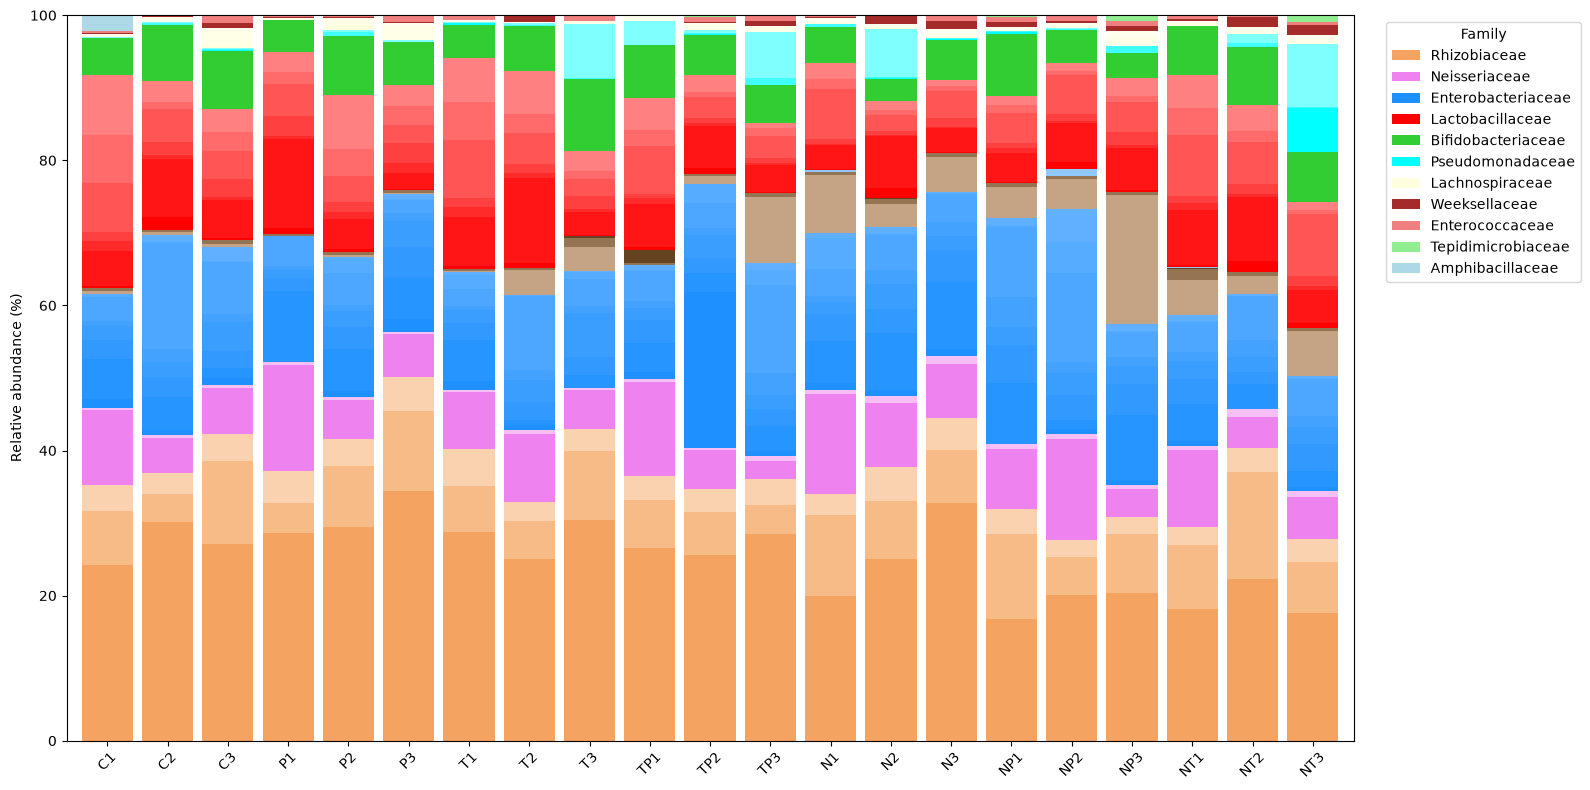

In [24]:
family_colors = {
    "Rhizobiaceae": "sandybrown",  # Bartonellaceae
    "Neisseriaceae": "violet",
    "Enterobacteriaceae": "dodgerblue",  # Orbaceae
    "Lactobacillaceae": "red",
    "Leuconostocaceae": "orange",
    "Bifidobacteriaceae": "limegreen",
    # not in the original paper
    "Pseudomonadaceae": "cyan",
    "Lachnospiraceae": "lightyellow",
    "Weeksellaceae": "brown",
    "Enterococcaceae": "lightcoral",
    "Tepidimicrobiaceae": "lightgreen",
    "Amphibacillaceae": "lightblue",
}

def make_family_shades(base_color, n):
    if n <= 1:
        return [mcolors.to_hex(base_color)]
    base_rgb = np.array(mcolors.to_rgb(base_color))
    white = np.array([1.0, 1.0, 1.0])
    factors = np.linspace(0.0, 0.5, n)
    return [mcolors.to_hex(base_rgb * (1 - f) + white * f) for f in factors]

def make_color_gradient(start_color, end_color, n):
    if n <= 1:
        return [mcolors.to_hex(start_color)]
    start_rgb = np.array(mcolors.to_rgb(start_color))
    end_rgb = np.array(mcolors.to_rgb(end_color))
    factors = np.linspace(0.0, 1.0, n)
    return [mcolors.to_hex(start_rgb * (1 - f) + end_rgb * f) for f in factors]

family_order = list(family_colors.keys())
family_rank = {family: rank for rank, family in enumerate(family_order)}

# Reorder species rows so stacked bars follow the requested family order
index_df = mq_relative_abund_df.index.to_frame(index=False)
index_df["sort_rank"] = index_df["Family"].map(family_rank).fillna(len(family_order)).astype(int)
index_df = index_df.sort_values(["sort_rank", "Family", "Genus", "Species"], kind="stable")
ordered_index = pd.MultiIndex.from_frame(index_df[["Family", "Genus", "Species"]])
species_abund_df_ordered = mq_relative_abund_df.loc[ordered_index]

# Default colors: same family hue, different shade within family
default_color_map = {}
for family_name, group in index_df.groupby("Family", sort=False):
    base_color = family_colors.get(family_name, "gray")
    shades = make_family_shades(base_color, len(group))
    for (_, row), shade in zip(group.iterrows(), shades):
        default_color_map[(row["Family"], row["Genus"], row["Species"])] = shade

# Special overrides requested by user
providencia_count = index_df["Genus"].astype(str).str.lower().str.startswith("providencia").sum()
providencia_shades = iter(make_color_gradient("#c4a484", "#654321", providencia_count))

species_colors = []
for _, row in index_df.iterrows():
    family_name = row["Family"]
    genus_name = str(row["Genus"]).strip().lower()
    species_name = str(row["Species"]).strip().lower()
    key = (row["Family"], row["Genus"], row["Species"])
    if genus_name.startswith("arsenophonus") and species_name == "apicola":
        color = "black"
    elif genus_name.startswith("proteus"):
        color = "#c4a484"  # light brown
    elif genus_name.startswith("providencia"):
        color = next(providencia_shades)
    else:
        color = default_color_map.get(key, family_colors.get(family_name, "gray"))
    species_colors.append(color)

fig, ax = plt.subplots(figsize=(16, 8))
species_abund_df_ordered.T.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=species_colors,
    width=0.85,
    legend=False,
 )

ax.set_ylabel("Relative abundance (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=45)

present_families = [family for family in family_order if family in set(index_df["Family"])]
legend_handles = [
    Patch(facecolor=family_colors.get(family, "gray"), label=family)
    for family in present_families
]
ax.legend(handles=legend_handles, title="Family", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
png_fp = result_dp / "mq_taxonomy_relative_abundance_biplot.png"
fig.savefig(png_fp, dpi=300, bbox_inches="tight")
plt.show()

Saved PCA biplot to: ../results/bee-use-case/mq_taxonomy_pca_biplot.png


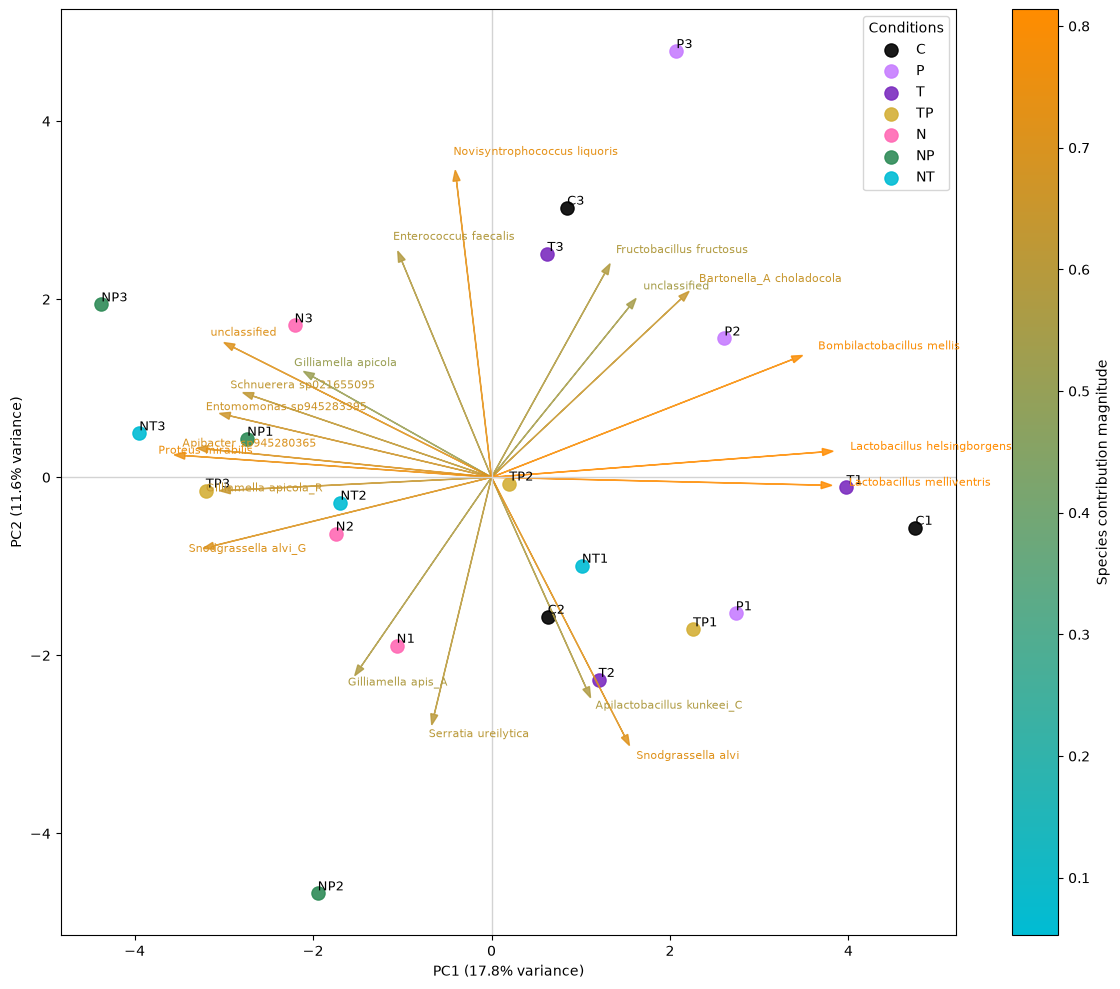

,PC1,PC2,Category
C1,4.750747,-0.566975,C
C2,0.629802,-1.566032,C
C3,0.847377,3.027012,C
P1,2.737088,-1.527675,P
P2,2.609259,1.558581,P
P3,2.071252,4.785914,P
T1,3.978256,-0.111046,T
T2,1.200842,-2.275568,T
T3,0.626372,2.508036,T
TP1,2.258723,-1.707807,TP


In [25]:
sample_matrix = mq_relative_abund_df.select_dtypes(include=[np.number]).T

scaled_sample_matrix = StandardScaler().fit_transform(sample_matrix)
pca = PCA(n_components=2)
sample_scores = pca.fit_transform(scaled_sample_matrix)
species_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

sample_scores_df = pd.DataFrame(sample_scores, index=sample_matrix.index, columns=["PC1", "PC2"])
sample_scores_df["Category"] = (
    sample_scores_df.index.to_series()
    .str.extract(r"^(NT|NP|TP|C|T|P|N)", expand=False)
    .fillna("Other")
)

category_palette = {
    "C": "#000000",
    "T": "#7b2cbf",
    "P": "#c77dff",
    "N": "#ff69b4",
    "NT": "#00bcd4",
    "NP": "#2e8b57",
    "TP": "#d4af37",
    "Other": "#6c757d",
}

species_contribution = np.linalg.norm(species_loadings, axis=1)
contribution_norm = plt.Normalize(species_contribution.min(), species_contribution.max())
arrow_cmap = LinearSegmentedColormap.from_list("cyan_orange", ["#00bcd4", "#ff8c00"])
arrow_colors = arrow_cmap(contribution_norm(species_contribution))

top_species_idx = np.argsort(species_contribution)[-20:]
score_limit = np.abs(sample_scores_df[["PC1", "PC2"]].to_numpy()).max()
loading_limit = np.abs(species_loadings[top_species_idx]).max()
arrow_scale = 1.0 if loading_limit == 0 else (score_limit / loading_limit) * 0.8

fig, ax = plt.subplots(figsize=(12, 10))

for category, frame in sample_scores_df.groupby("Category", sort=False):
    ax.scatter(
        frame["PC1"],
        frame["PC2"],
        s=90,
        color=category_palette.get(category, category_palette["Other"]),
        label=category,
        alpha=0.9,
    )
    for sample_name, row in frame.iterrows():
        ax.text(row["PC1"], row["PC2"], sample_name, fontsize=9, ha="left", va="bottom")

for idx in top_species_idx:
    species_name = mq_relative_abund_df.index[idx][2]
    x_loading = species_loadings[idx, 0] * arrow_scale
    y_loading = species_loadings[idx, 1] * arrow_scale
    ax.arrow(
        0,
        0,
        x_loading,
        y_loading,
        color=arrow_colors[idx],
        alpha=0.85,
        width=0.002,
        head_width=0.08,
        length_includes_head=True,
    )
    ax.text(x_loading * 1.05, y_loading * 1.05, species_name, color=arrow_colors[idx], fontsize=8)

explained_variance = pca.explained_variance_ratio_ * 100
ax.axhline(0, color="lightgray", linewidth=1)
ax.axvline(0, color="lightgray", linewidth=1)
ax.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_variance[1]:.1f}% variance)")
ax.legend(title="Conditions")

sm = plt.cm.ScalarMappable(cmap=arrow_cmap, norm=contribution_norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Species contribution magnitude")

plt.tight_layout()
png_fp = result_dp / "mq_taxonomy_pca_biplot.png"
fig.savefig(png_fp, dpi=300, bbox_inches="tight")
print(f"Saved PCA biplot to: {png_fp}")
plt.show()

sample_scores_df

### Functions

In [26]:
print_stats(get_bakta_annot_df(mq_df).describe())

CDSs: 2456.22 ± 1045.57, Median: 2201.00, IQR: 1570.00-3134.00, Range: 977.00-4991.00
CRISPR arrays: 1.30 ± 2.12, Median: 0.00, IQR: 0.00-2.00, Range: 0.00-9.00
gaps: 0.00 ± 0.00, Median: 0.00, IQR: 0.00-0.00, Range: 0.00-0.00
hypotheticals: 245.84 ± 215.33, Median: 180.00, IQR: 80.00-306.00, Range: 42.00-874.00
ncRNA regions: 19.57 ± 13.87, Median: 15.00, IQR: 9.00-27.00, Range: 2.00-57.00
ncRNAs: 15.62 ± 17.28, Median: 7.00, IQR: 5.00-22.00, Range: 2.00-73.00
oriCs: 0.57 ± 0.65, Median: 0.00, IQR: 0.00-1.00, Range: 0.00-2.00
oriTs: 0.05 ± 0.23, Median: 0.00, IQR: 0.00-0.00, Range: 0.00-1.00
oriVs: 0.00 ± 0.00, Median: 0.00, IQR: 0.00-0.00, Range: 0.00-0.00
pseudogenes: 13.14 ± 13.84, Median: 8.00, IQR: 4.00-16.00, Range: 0.00-57.00
rRNAs: 2.05 ± 2.50, Median: 2.00, IQR: 0.00-3.00, Range: 0.00-13.00
sORFs: 1.24 ± 2.70, Median: 0.00, IQR: 0.00-1.00, Range: 0.00-12.00
signal peptides: 0.00 ± 0.00, Median: 0.00, IQR: 0.00-0.00, Range: 0.00-0.00
tRNAs: 40.22 ± 15.66, Median: 39.00, IQR: 3

In [27]:
mq_kegg_module_df = get_kegg_path_df(mq_df)

Before removing rows and columns with only zeros:
Clusters: 37
KEGG modules: 306

After removing rows and columns with only zeros:
Clusters: 32
KEGG modules: 301

KEGG modules: 169.16 ± 36.77, Median: 173.50, IQR: 146.75-193.00, Range: 102.00-229.00


In [28]:
# Count how many KEGG pathways reach a given completeness threshold for each MAG
thresholds = [50, 75, 100]
kegg_path_counts_df = pd.DataFrame(index=mq_kegg_module_df.index)

for threshold in thresholds:
    kegg_path_counts_df[f"Modules with completeness >= {threshold}%"] = (mq_kegg_module_df >= threshold).sum(axis=1)

kegg_path_counts_df = kegg_path_counts_df.sort_values(by="Modules with completeness >= 50%", ascending=False)
kegg_path_counts_df.describe()

,Modules with completeness >= 50%,Modules with completeness >= 75%,Modules with completeness >= 100%
count,32.000000,32.00000,32.000000
mean,96.593750,58.78125,40.312500
std,37.268736,27.51508,23.647188
min,31.000000,10.00000,5.000000
25%,73.500000,41.50000,24.500000
50%,94.500000,56.50000,37.000000
75%,122.500000,79.25000,52.000000
max,171.000000,116.00000,98.000000


In [29]:
# Count in how many MAGs a KEGG pathway reaches a given completeness threshold
kegg_pathway_mag_counts_df = pd.DataFrame(index=mq_kegg_module_df.columns)

for threshold in thresholds:
    kegg_pathway_mag_counts_df[f"MAGs with completeness >= {threshold}%"] = (mq_kegg_module_df >= threshold).sum(axis=0)

kegg_pathway_mag_counts_df = kegg_pathway_mag_counts_df.sort_values(by="MAGs with completeness >= 50%", ascending=False)
kegg_pathway_mag_counts_df

,MAGs with completeness >= 50%,MAGs with completeness >= 75%,MAGs with completeness >= 100%
"Guanine ribonucleotide biosynthesis, IMP => GDP,GTP",32,29,17
"Nucleotide sugar biosynthesis, glucose => UDP-glucose",32,18,18
"Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate",32,27,13
"C1-unit interconversion, prokaryotes",32,14,14
Pentose phosphate pathway (Pentose phosphate cycle),32,23,12
...,...,...,...
"Pyocyanine biosynthesis, chorismate => pyocyanine",0,0,0
Hydroxypropionate-hydroxybutylate cycle,0,0,0
"Incomplete reductive citrate cycle, acetyl-CoA => oxoglutarate",0,0,0
"Inositol phosphate metabolism, Ins(1,3,4,5)P4 => Ins(1,3,4)P3 => myo-inositol",0,0,0


In [30]:
print(f"Number of pathways with completeness < 50% in all MAG: {((mq_kegg_module_df < 50).all(axis=0)).sum()}")
print(f"Number of pathways with completeness < 75% in all MAG: {((mq_kegg_module_df < 75).all(axis=0)).sum()}")
print(f"Number of pathways with completeness >= 50 % in all MAG: {((mq_kegg_module_df >= 50).all(axis=0)).sum()}")
print(f"Number of pathways with completeness >= 75 % in all MAG: {((mq_kegg_module_df >= 75).all(axis=0)).sum()}")

Number of pathways with completeness < 50% in all MAG: 90
Number of pathways with completeness < 75% in all MAG: 144
Number of pathways with completeness >= 50 % in all MAG: 6
Number of pathways with completeness >= 75 % in all MAG: 0


In [31]:
kegg_pathway_mag_counts_df.index[kegg_pathway_mag_counts_df.iloc[:, 0].eq(32)].tolist()

['Guanine ribonucleotide biosynthesis, IMP => GDP,GTP',
 'Nucleotide sugar biosynthesis, glucose => UDP-glucose',
 'Glycolysis (Embden-Meyerhof pathway), glucose => pyruvate',
 'C1-unit interconversion, prokaryotes',
 'Pentose phosphate pathway (Pentose phosphate cycle)',
 'F-type ATPase, prokaryotes and chloroplasts']

### LQ: Low-quality species-level clusters (contamination < 10% and completeness < 50%)

In [32]:
lq_df = reps_df.query("Contamination < 10 and Completeness < 50")
compute_print_stats(lq_df)

Total number: 0.0
Cluster members: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
Contamination: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
Completeness: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan
Total length: nan ± nan, Median: nan, IQR: nan-nan, Range: nan-nan


## Relative abundance with all MAGs

In [33]:
abund_df = get_relative_abund_taxo_levels(reps_df, coverage_df)


Level: Family


,count,mean,std,min,25%,50%,75%,max
Family,,,,,,,,
Rhizobiaceae,21.0,60.505580,7.591618,45.480977,56.610533,61.350515,64.777408,73.699800
Enterobacteriaceae,21.0,16.133637,5.985195,8.359945,10.391449,15.604288,19.485668,28.563726
Lactobacillaceae,21.0,11.413629,3.875610,5.701365,7.751968,11.151313,14.027810,18.554947
Neisseriaceae,21.0,5.282950,2.324024,2.019276,3.554161,4.798950,6.798180,10.470156
Bifidobacteriaceae,21.0,3.832472,1.232510,1.741362,3.058149,3.420026,4.747697,6.359980
Pseudomonadaceae,21.0,1.510607,2.726504,0.000000,0.176321,0.274110,0.962521,11.297384
Lachnospiraceae,21.0,0.577212,0.410183,0.092606,0.289339,0.481086,0.658089,1.431038
Weeksellaceae,21.0,0.311876,0.288424,0.000000,0.078152,0.168933,0.549101,1.034974
Enterococcaceae,21.0,0.298881,0.186620,0.000000,0.150152,0.322716,0.441370,0.574477



Level: Genus


,count,mean,std,min,25%,50%,75%,max
Genus,,,,,,,,
Bartonella_A,21.0,60.505580,7.591618,45.480977,56.610533,61.350515,64.777408,73.699800
Gilliamella,21.0,8.847692,3.563307,4.258849,6.635353,7.939835,9.712341,17.572240
Lactobacillus,21.0,6.219665,2.838695,2.443484,4.094802,5.283360,8.100000,12.510318
Snodgrassella,21.0,5.282950,2.324024,2.019276,3.554161,4.798950,6.798180,10.470156
Apilactobacillus,21.0,4.002815,1.887933,1.215120,2.572510,3.826619,4.914010,8.417777
Bifidobacterium,21.0,3.832472,1.232510,1.741362,3.058149,3.420026,4.747697,6.359980
Frischella,21.0,2.987899,1.669882,0.504743,1.681749,2.988504,3.703817,6.355265
Proteus,21.0,2.151310,2.841544,0.000000,0.152058,1.526562,2.747867,12.392208
Entomomonas,21.0,1.510607,2.726504,0.000000,0.176321,0.274110,0.962521,11.297384



Level: Species


,count,mean,std,min,25%,50%,75%,max
Species,,,,,,,,
unclassified,21.0,41.476662,6.882964,30.130442,33.922268,41.981927,46.819984,52.727278
Bartonella_A choladocola,21.0,15.506520,2.767248,10.473994,14.005724,14.409031,18.143176,20.701200
Snodgrassella alvi,21.0,4.928714,2.306331,1.584527,3.296549,4.189149,6.445547,9.992375
Bartonella_A sp945285915,21.0,4.834028,1.588519,2.359357,3.789697,4.596294,5.995426,8.043159
Bifidobacterium indicum,21.0,3.832472,1.232510,1.741362,3.058149,3.420026,4.747697,6.359980
Gilliamella apis_A,21.0,3.772716,2.570653,0.942677,2.224595,2.738887,3.793257,10.096527
Apilactobacillus kunkeei_C,21.0,3.650920,1.691853,1.154201,2.481564,3.423945,4.085453,7.981385
Lactobacillus apis,21.0,3.033031,1.377000,1.317706,1.979110,2.910963,3.911632,6.400746
Frischella perrara,21.0,2.987899,1.669882,0.504743,1.681749,2.988504,3.703817,6.355265


In [34]:
run_to_replicate = metadata_df.set_index("Run accession")["Replicate"].to_dict()
abund_df = abund_df.rename(
    columns={
        column: run_to_replicate[column]
        for column in abund_df.columns
        if column.startswith("SRR") and column in run_to_replicate
    }
)

abund_df =abund_df[[*sample_order]]
abund_df.head()

C1  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  1.229708   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  2.914923   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.660237   
                   Frischella      Frischella perrara       3.183809   
                   Gilliamella     Gilliamella apicola      1.545443   

                                                                  C2  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  5.336143   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.451788   
                   Frischella      Frischella perrara       3.131108   
                   Gilliamella     Gilliamella apicola      1.947186   

                                                                  C3  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.014847   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  4.191349   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.514172   
                   Frischella      Frischella perrara       0.666841   
                   Gilliamella     Gilliamella apicola      1.245766   

                                                                  P1  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  2.491640   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.000000   
                   Frischella      Frischella perrara       5.434329   
                   Gilliamella     Gilliamella apicola      1.044959   

                                                                  P2  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  5.169363   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.514249   
                   Frischella      Frischella perrara       3.703817   
                   Gilliamella     Gilliamella apicola      1.943321   

                                                                  P3  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  3.188804   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.931716   
                   Frischella      Frischella perrara       2.988504   
                   Gilliamella     Gilliamella apicola      2.272571   

                                                                  T1  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  2.278937   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.628392   
                   Frischella      Frischella perrara       2.838377   
                   Gilliamella     Gilliamella apicola      1.135822   

                                                                  T2  \
Family             Genus           Species                             
Amphibacillaceae   Virgibacillus   Virgibacillus proomii_B  0.000000   
Bifidobacteriaceae Bifidobacterium Bifidobacterium indicum  4.241876   
Enterobacteriaceae Arsenophonus    Arsenophonus apicola     0.442469   
                   Frischella      Frischella perrara       0.504743   
                   Gilliamella     Gilliamella apicola      1.727883   

                          

### Relative abundance of control data

In [35]:
control_species_abund_df = abund_df[["C1", "C2", "C3"]]
control_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False)

count  \
Family             Genus               Species                                 
Rhizobiaceae       Bartonella_A        unclassified                      3.0   
                                       Bartonella_A choladocola          3.0   
Enterobacteriaceae Gilliamella         Gilliamella apis_A                3.0   
Rhizobiaceae       Bartonella_A        Bartonella_A sp945285915          3.0   
Neisseriaceae      Snodgrassella       Snodgrassella alvi                3.0   
Bifidobacteriaceae Bifidobacterium     Bifidobacterium indicum           3.0   
Lactobacillaceae   Apilactobacillus    Apilactobacillus kunkeei_C        3.0   
                   Lactobacillus       Lactobacillus apis                3.0   
                                       Lactobacillus melliventris        3.0   
Enterobacteriaceae Frischella          Frischella perrara                3.0   
Lactobacillaceae   Lactobacillus       Lactobacillus helsingborgensis    3.0   
Enterobacteriaceae Gilliamella         Gilliamella apicola               3.0   
                                       Gilliamella apicola_N             3.0   
Lactobacillaceae   Fructobacillus      Fructobacillus fructosus          3.0   
Enterobacteriaceae Gilliamella         Gilliamella apicola_R             3.0   
                   Klebsiella          Klebsiella oxytoca                3.0   
                   Arsenophonus        Arsenophonus apicola              3.0   
Lachnospiraceae    Novisyntrophococcus Novisyntrophococcus liquoris      3.0   
Lactobacillaceae   Apilactobacillus    Apilactobacillus apinorum         3.0   
                   Bombilactobacillus  Bombilactobacillus mellis         3.0   
Amphibacillaceae   Virgibacillus       Virgibacillus proomii_B           3.0   
Enterococcaceae    Enterococcus        Enterococcus faecalis             3.0   
Enterobacteriaceae Providencia         Providencia rettgeri              3.0   
Neisseriaceae      Snodgrassella       Snodgrassella alvi_G              3.0   
Weeksellaceae      Apibacter           Apibacter sp945280365             3.0   
Enterobacteriaceae Proteus             Proteus mirabilis                 3.0   
                   Gilliamella         Gilliamella sp945271295           3.0   
Pseudomonadaceae   Entomomonas         unclassified                      3.0   
Lachnospiraceae    Novisyntrophococcus unclassified                      3.0   
                   Mobilisporobacter   unclassified                      3.0   
Pseudomonadaceae   Entomomonas         Entomomonas sp945283395           3.0   
Enterobacteriaceae Providencia         Providencia alcalifaciens         3.0   
Pseudomonadaceae   Entomomonas         Entomomonas moraniae              3.0   
Enterobacteriaceae Serratia            Serratia ureilytica               3.0   
                   Providencia         Providencia rettgeri_D            3.0   
Tepidimicrobiaceae Schnuerera          Schnuerera sp021655095            3.0   

                                                                            mean  \
Family             Genus               Species                                     
Rhizobiaceae       Bartonella_A        unclassified                    42.488926   
                                       Bartonella_A choladocola        16.255337   
Enterobacteriaceae Gilliamella         Gilliamella apis_A               5.231149   
Rhizobiaceae       Bartonella_A        Bartonella_A sp945285915         4.330412   
Neisseriaceae      Snodgrassella       Snodgrassella alvi               4.173978   
Bifidobacteriaceae Bifidobacterium     Bifidobacterium indicum          4.147472   
Lactobacillaceae   Apilactobacillus    Apilactobacillus kunkeei_C       3.668888   
                   Lactobacillus       Lactobacillus apis               2.990514   
                                       Lactobacillus melliventris       2.831876   
Enterobacteriaceae Frischella          Frischella perrara               2.327253   
Lactobacillaceae   Lac

In [36]:
control_species_abund_df.xs("Bartonella_A", level=1, axis=0, drop_level=False).sum(axis=0).describe()

count     3.000000
mean     63.074675
std       6.727555
min      56.610533
25%      59.593086
50%      62.575640
75%      66.306746
max      70.037852
dtype: float64

### Relative abundance of all experimental conditions

In [37]:
control_species_abund_df = abund_df[["C1", "C2", "C3"]]
display(control_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False))

infected_species_abund_df = abund_df[["N1", "N2", "N3"]]
display(infected_species_abund_df.T.describe().T.sort_values(by="mean", ascending=False))

count  \
Family             Genus               Species                                 
Rhizobiaceae       Bartonella_A        unclassified                      3.0   
                                       Bartonella_A choladocola          3.0   
Enterobacteriaceae Gilliamella         Gilliamella apis_A                3.0   
Rhizobiaceae       Bartonella_A        Bartonella_A sp945285915          3.0   
Neisseriaceae      Snodgrassella       Snodgrassella alvi                3.0   
Bifidobacteriaceae Bifidobacterium     Bifidobacterium indicum           3.0   
Lactobacillaceae   Apilactobacillus    Apilactobacillus kunkeei_C        3.0   
                   Lactobacillus       Lactobacillus apis                3.0   
                                       Lactobacillus melliventris        3.0   
Enterobacteriaceae Frischella          Frischella perrara                3.0   
Lactobacillaceae   Lactobacillus       Lactobacillus helsingborgensis    3.0   
Enterobacteriaceae Gilliamella         Gilliamella apicola               3.0   
                                       Gilliamella apicola_N             3.0   
Lactobacillaceae   Fructobacillus      Fructobacillus fructosus          3.0   
Enterobacteriaceae Gilliamella         Gilliamella apicola_R             3.0   
                   Klebsiella          Klebsiella oxytoca                3.0   
                   Arsenophonus        Arsenophonus apicola              3.0   
Lachnospiraceae    Novisyntrophococcus Novisyntrophococcus liquoris      3.0   
Lactobacillaceae   Apilactobacillus    Apilactobacillus apinorum         3.0   
                   Bombilactobacillus  Bombilactobacillus mellis         3.0   
Amphibacillaceae   Virgibacillus       Virgibacillus proomii_B           3.0   
Enterococcaceae    Enterococcus        Enterococcus faecalis             3.0   
Enterobacteriaceae Providencia         Providencia rettgeri              3.0   
Neisseriaceae      Snodgrassella       Snodgrassella alvi_G              3.0   
Weeksellaceae      Apibacter           Apibacter sp945280365             3.0   
Enterobacteriaceae Proteus             Proteus mirabilis                 3.0   
                   Gilliamella         Gilliamella sp945271295           3.0   
Pseudomonadaceae   Entomomonas         unclassified                      3.0   
Lachnospiraceae    Novisyntrophococcus unclassified                      3.0   
                   Mobilisporobacter   unclassified                      3.0   
Pseudomonadaceae   Entomomonas         Entomomonas sp945283395           3.0   
Enterobacteriaceae Providencia         Providencia alcalifaciens         3.0   
Pseudomonadaceae   Entomomonas         Entomomonas moraniae              3.0   
Enterobacteriaceae Serratia            Serratia ureilytica               3.0   
                   Providencia         Providencia rettgeri_D            3.0   
Tepidimicrobiaceae Schnuerera          Schnuerera sp021655095            3.0   

                                                                            mean  \
Family             Genus               Species                                     
Rhizobiaceae       Bartonella_A        unclassified                    42.488926   
                                       Bartonella_A choladocola        16.255337   
Enterobacteriaceae Gilliamella         Gilliamella apis_A               5.231149   
Rhizobiaceae       Bartonella_A        Bartonella_A sp945285915         4.330412   
Neisseriaceae      Snodgrassella       Snodgrassella alvi               4.173978   
Bifidobacteriaceae Bifidobacterium     Bifidobacterium indicum          4.147472   
Lactobacillaceae   Apilactobacillus    Apilactobacillus kunkeei_C       3.668888   
                   Lactobacillus       Lactobacillus apis               2.990514   
                                       Lactobacillus melliventris       2.831876   
Enterobacteriaceae Frischella          Frischella perrara               2.327253   
Lactobacillaceae   Lac

count  \
Family             Genus               Species                                 
Rhizobiaceae       Bartonella_A        unclassified                      3.0   
                                       Bartonella_A choladocola          3.0   
Neisseriaceae      Snodgrassella       Snodgrassella alvi                3.0   
Rhizobiaceae       Bartonella_A        Bartonella_A sp945285915          3.0   
Enterobacteriaceae Frischella          Frischella perrara                3.0   
                   Proteus             Proteus mirabilis                 3.0   
Lactobacillaceae   Apilactobacillus    Apilactobacillus kunkeei_C        3.0   
Bifidobacteriaceae Bifidobacterium     Bifidobacterium indicum           3.0   
Lactobacillaceae   Lactobacillus       Lactobacillus apis                3.0   
Enterobacteriaceae Gilliamella         Gilliamella apis_A                3.0   
                                       Gilliamella apicola               3.0   
                                       Gilliamella apicola_N             3.0   
Pseudomonadaceae   Entomomonas         unclassified                      3.0   
Enterobacteriaceae Gilliamella         Gilliamella sp945271295           3.0   
                                       Gilliamella apicola_R             3.0   
Lactobacillaceae   Lactobacillus       Lactobacillus melliventris        3.0   
                                       Lactobacillus helsingborgensis    3.0   
Enterobacteriaceae Arsenophonus        Arsenophonus apicola              3.0   
Neisseriaceae      Snodgrassella       Snodgrassella alvi_G              3.0   
Lactobacillaceae   Fructobacillus      Fructobacillus fructosus          3.0   
Weeksellaceae      Apibacter           Apibacter sp945280365             3.0   
Lactobacillaceae   Apilactobacillus    Apilactobacillus apinorum         3.0   
Enterobacteriaceae Klebsiella          Klebsiella oxytoca                3.0   
                   Providencia         Providencia rettgeri              3.0   
Lachnospiraceae    Novisyntrophococcus Novisyntrophococcus liquoris      3.0   
Enterococcaceae    Enterococcus        Enterococcus faecalis             3.0   
Lachnospiraceae    Novisyntrophococcus unclassified                      3.0   
Pseudomonadaceae   Entomomonas         Entomomonas sp945283395           3.0   
Lactobacillaceae   Bombilactobacillus  Bombilactobacillus mellis         3.0   
Enterobacteriaceae Serratia            Serratia ureilytica               3.0   
Lachnospiraceae    Mobilisporobacter   unclassified                      3.0   
Enterobacteriaceae Providencia         Providencia alcalifaciens         3.0   
Pseudomonadaceae   Entomomonas         Entomomonas moraniae              3.0   
Enterobacteriaceae Providencia         Providencia rettgeri_D            3.0   
Tepidimicrobiaceae Schnuerera          Schnuerera sp021655095            3.0   
Amphibacillaceae   Virgibacillus       Virgibacillus proomii_B           3.0   

                                                                            mean  \
Family             Genus               Species                                     
Rhizobiaceae       Bartonella_A        unclassified                    44.101934   
                                       Bartonella_A choladocola        14.981308   
Neisseriaceae      Snodgrassella       Snodgrassella alvi               5.915927   
Rhizobiaceae       Bartonella_A        Bartonella_A sp945285915         5.153255   
Enterobacteriaceae Frischella          Frischella perrara               4.423373   
                   Proteus             Proteus mirabilis                3.143742   
Lactobacillaceae   Apilactobacillus    Apilactobacillus kunkeei_C       2.648855   
Bifidobacteriaceae Bifidobacterium     Bifidobacterium indicum          2.621438   
Lactobacillaceae   Lactobacillus       Lactobacillus apis               2.546922   
Enterobacteriaceae Gilliamella         Gilliamella apis_A               2.393769   
                      

In [38]:
for sample in abund_df.columns:
    print(f"Sample: {sample}")
    top_species = abund_df[sample].nlargest(5)
    display(top_species)

Sample: C1


Family            Genus          Species                   
Rhizobiaceae      Bartonella_A   unclassified                  44.282552
                                 Bartonella_A choladocola      14.005724
Neisseriaceae     Snodgrassella  Snodgrassella alvi             5.949344
Lactobacillaceae  Lactobacillus  Lactobacillus melliventris     4.814544
Rhizobiaceae      Bartonella_A   Bartonella_A sp945285915       4.287363
Name: C1, dtype: float64

Sample: C2


Family              Genus             Species                   
Rhizobiaceae        Bartonella_A      unclassified                  33.200887
                                      Bartonella_A choladocola      20.701200
Enterobacteriaceae  Gilliamella       Gilliamella apis_A            10.096527
Lactobacillaceae    Apilactobacillus  Apilactobacillus kunkeei_C     5.525052
Bifidobacteriaceae  Bifidobacterium   Bifidobacterium indicum        5.336143
Name: C2, dtype: float64

Sample: C3


...

Family            Genus          Species                 
Rhizobiaceae      Bartonella_A   unclassified                32.610192
                                 Bartonella_A choladocola    12.506447
Neisseriaceae     Snodgrassella  Snodgrassella alvi           7.270157
Rhizobiaceae      Bartonella_A   Bartonella_A sp945285915     6.123164
Lactobacillaceae  Lactobacillus  Lactobacillus apis           5.826096
Name: NT1, dtype: float64

Sample: NT2


Family              Genus             Species                   
Rhizobiaceae        Bartonella_A      unclassified                  47.398161
                                      Bartonella_A choladocola      12.129357
                                      Bartonella_A sp945285915       8.043159
Lactobacillaceae    Apilactobacillus  Apilactobacillus kunkeei_C     4.792278
Bifidobacteriaceae  Bifidobacterium   Bifidobacterium indicum        4.344046
Name: NT2, dtype: float64

Sample: NT3


Family            Genus          Species                 
Rhizobiaceae      Bartonella_A   unclassified                26.902670
                                 Bartonella_A choladocola    13.273750
Pseudomonadaceae  Entomomonas    unclassified                 6.615464
Lactobacillaceae  Lactobacillus  Lactobacillus apis           6.400746
Rhizobiaceae      Bartonella_A   Bartonella_A sp945285915     5.304557
Name: NT3, dtype: float64

In [39]:
arsenophonus_abund_df = abund_df.xs("Arsenophonus apicola", level=2, axis=0, drop_level=False).T
print(f"Abundance for Arsenophonus apicola in TP2: {arsenophonus_abund_df.loc['TP2'].values[0]}")
print("Abundance for Arsenophonus apicola without TP2 sample: ")
arsenophonus_abund_df.drop(["TP2"]).describe().T

Abundance for Arsenophonus apicola in TP2: 13.512226651028419
Abundance for Arsenophonus apicola without TP2 sample: 


,,,count,mean,std,min,25%,50%,75%,max
Family,Genus,Species,,,,,,,,
Enterobacteriaceae,Arsenophonus,Arsenophonus apicola,20.0,0.434343,0.246459,0.0,0.449458,0.49032,0.531059,0.931716


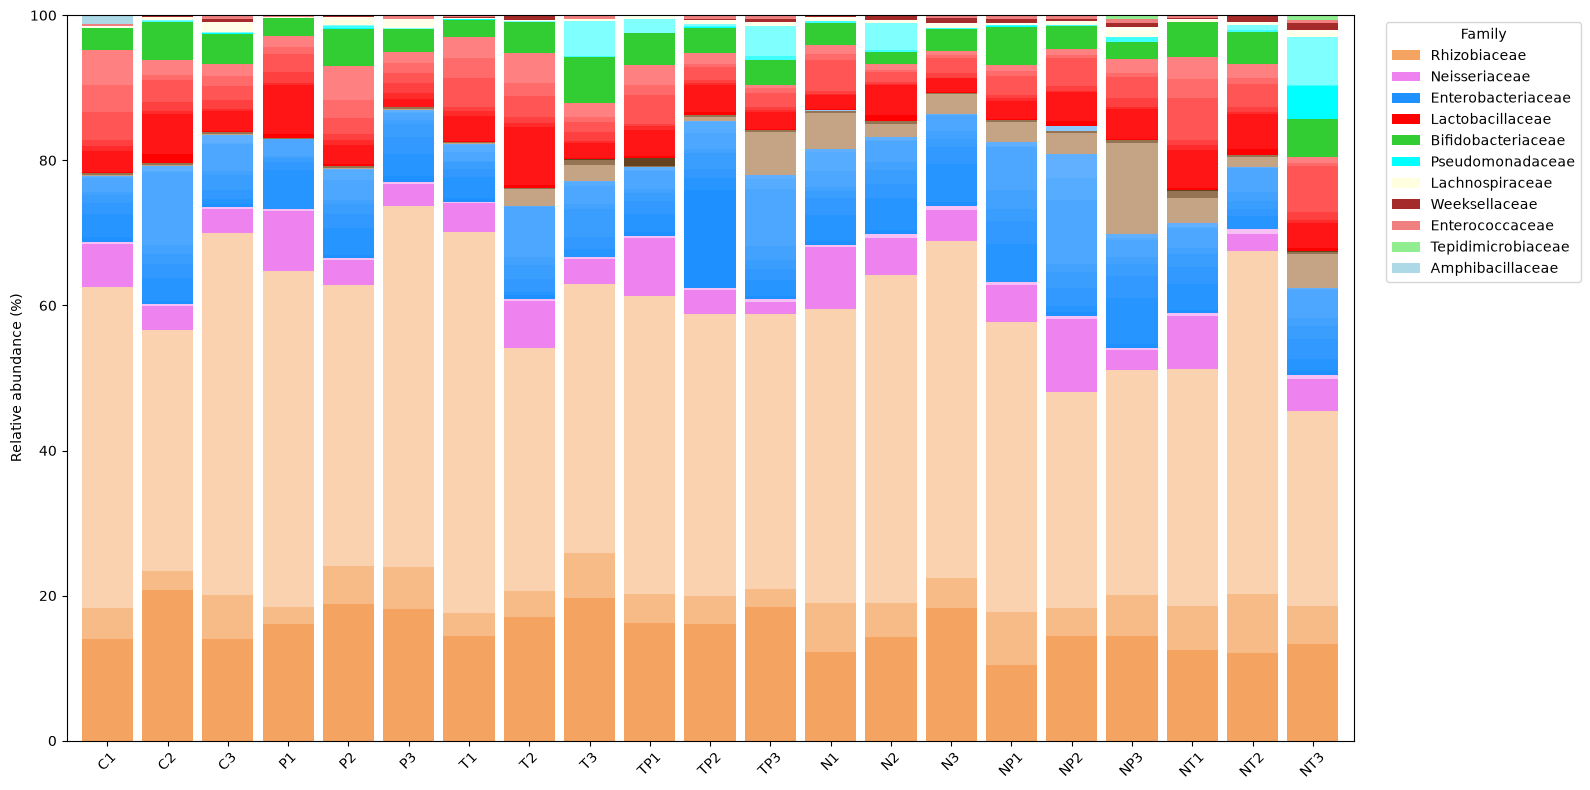

In [40]:
# Reorder species rows so stacked bars follow the requested family order
index_df = abund_df.index.to_frame(index=False)
index_df["sort_rank"] = index_df["Family"].map(family_rank).fillna(len(family_order)).astype(int)
index_df = index_df.sort_values(["sort_rank", "Family", "Genus", "Species"], kind="stable")
ordered_index = pd.MultiIndex.from_frame(index_df[["Family", "Genus", "Species"]])
species_abund_df_ordered = abund_df.loc[ordered_index]

# Default colors: same family hue, different shade within family
default_color_map = {}
for family_name, group in index_df.groupby("Family", sort=False):
    base_color = family_colors.get(family_name, "gray")
    shades = make_family_shades(base_color, len(group))
    for (_, row), shade in zip(group.iterrows(), shades):
        default_color_map[(row["Family"], row["Genus"], row["Species"])] = shade

# Special overrides requested by user
providencia_count = index_df["Genus"].astype(str).str.lower().str.startswith("providencia").sum()
providencia_shades = iter(make_color_gradient("#c4a484", "#654321", providencia_count))

species_colors = []
for _, row in index_df.iterrows():
    family_name = row["Family"]
    genus_name = str(row["Genus"]).strip().lower()
    species_name = str(row["Species"]).strip().lower()
    key = (row["Family"], row["Genus"], row["Species"])
    if genus_name.startswith("arsenophonus") and species_name == "apicola":
        color = "black"
    elif genus_name.startswith("proteus"):
        color = "#c4a484"  # light brown
    elif genus_name.startswith("providencia"):
        color = next(providencia_shades)
    else:
        color = default_color_map.get(key, family_colors.get(family_name, "gray"))
    species_colors.append(color)

fig, ax = plt.subplots(figsize=(16, 8))
species_abund_df_ordered.T.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=species_colors,
    width=0.85,
    legend=False,
 )

ax.set_ylabel("Relative abundance (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=45)

present_families = [family for family in family_order if family in set(index_df["Family"])]
legend_handles = [
    Patch(facecolor=family_colors.get(family, "gray"), label=family)
    for family in present_families
]
ax.legend(handles=legend_handles, title="Family", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
png_fp = result_dp / "taxonomy_relative_abundance_biplot.png"
fig.savefig(png_fp, dpi=300, bbox_inches="tight")
plt.show()

### PCA

Saved PCA biplot to: ../results/bee-use-case/taxonomy_pca_biplot.png


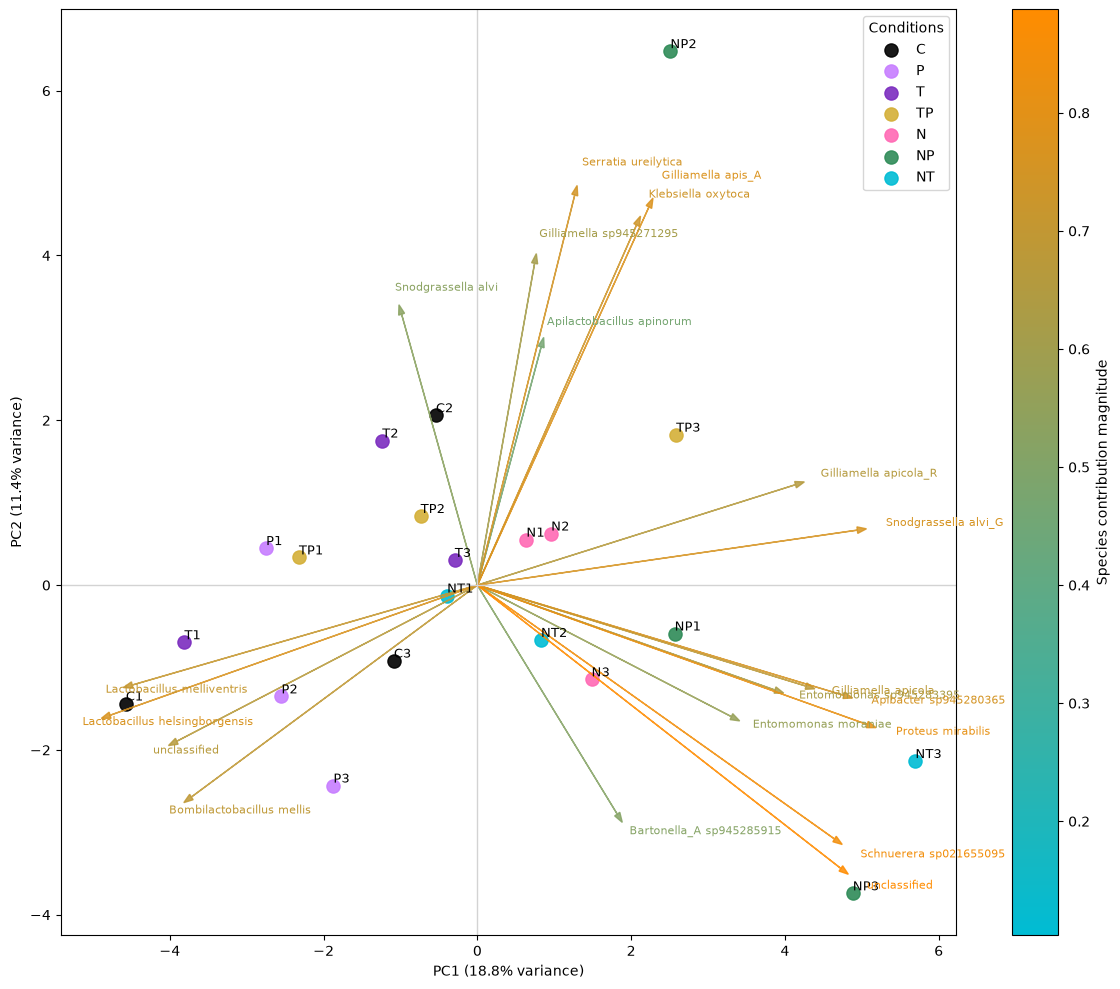

,PC1,PC2,Category
C1,-4.570935,-1.436631,C
C2,-0.538517,2.061712,C
C3,-1.085125,-0.917092,C
P1,-2.747159,0.449632,P
P2,-2.547741,-1.350481,P
P3,-1.872148,-2.433057,P
T1,-3.809287,-0.693279,T
T2,-1.236752,1.754782,T
T3,-0.292957,0.305178,T
TP1,-2.320190,0.335765,TP


In [41]:
sample_matrix = abund_df.select_dtypes(include=[np.number]).T

scaled_sample_matrix = StandardScaler().fit_transform(sample_matrix)
pca = PCA(n_components=2)
sample_scores = pca.fit_transform(scaled_sample_matrix)
species_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

sample_scores_df = pd.DataFrame(sample_scores, index=sample_matrix.index, columns=["PC1", "PC2"])
sample_scores_df["Category"] = (
    sample_scores_df.index.to_series()
    .str.extract(r"^(NT|NP|TP|C|T|P|N)", expand=False)
    .fillna("Other")
)

species_contribution = np.linalg.norm(species_loadings, axis=1)
contribution_norm = plt.Normalize(species_contribution.min(), species_contribution.max())
arrow_cmap = LinearSegmentedColormap.from_list("cyan_orange", ["#00bcd4", "#ff8c00"])
arrow_colors = arrow_cmap(contribution_norm(species_contribution))

top_species_idx = np.argsort(species_contribution)[-20:]
score_limit = np.abs(sample_scores_df[["PC1", "PC2"]].to_numpy()).max()
loading_limit = np.abs(species_loadings[top_species_idx]).max()
arrow_scale = 1.0 if loading_limit == 0 else (score_limit / loading_limit) * 0.8

fig, ax = plt.subplots(figsize=(12, 10))

for category, frame in sample_scores_df.groupby("Category", sort=False):
    ax.scatter(
        frame["PC1"],
        frame["PC2"],
        s=90,
        color=category_palette.get(category, category_palette["Other"]),
        label=category,
        alpha=0.9,
    )
    for sample_name, row in frame.iterrows():
        ax.text(row["PC1"], row["PC2"], sample_name, fontsize=9, ha="left", va="bottom")

for idx in top_species_idx:
    species_name = abund_df.index[idx][2]
    x_loading = species_loadings[idx, 0] * arrow_scale
    y_loading = species_loadings[idx, 1] * arrow_scale
    ax.arrow(
        0,
        0,
        x_loading,
        y_loading,
        color=arrow_colors[idx],
        alpha=0.85,
        width=0.002,
        head_width=0.08,
        length_includes_head=True,
    )
    ax.text(x_loading * 1.05, y_loading * 1.05, species_name, color=arrow_colors[idx], fontsize=8)

explained_variance = pca.explained_variance_ratio_ * 100
ax.axhline(0, color="lightgray", linewidth=1)
ax.axvline(0, color="lightgray", linewidth=1)
ax.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_variance[1]:.1f}% variance)")
ax.legend(title="Conditions")

sm = plt.cm.ScalarMappable(cmap=arrow_cmap, norm=contribution_norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Species contribution magnitude")

plt.tight_layout()
png_fp = result_dp / "taxonomy_pca_biplot.png"
fig.savefig(png_fp, dpi=300, bbox_inches="tight")
print(f"Saved PCA biplot to: {png_fp}")
plt.show()

sample_scores_df

## Comparison of MAGs taxonomy with original study

In [42]:
count = df_expert[
    df_expert["Origin"].astype(str).str.contains("Built MAG", na=False)
    & (df_expert["Differences between NCBI and GTDB taxonomies"] == "Yes")].shape[0]
print(f"Number of MAGs with differences between NCBI and GTDB taxonomies: {count}")

Number of MAGs with differences between NCBI and GTDB taxonomies: 20


### Statistics for MAGs origin

In [43]:
origin_df = df_expert["Origin"].value_counts(dropna=False).to_frame("count")
origin_df

,count
Origin,
"Built MAG, Species listed in the paper",19
Built MAG,19
Species listed in the paper,10


### Species identified by MAGs

#### Concordant = corresponding to species listed in the paper 

In [44]:
concordant_mags = df_expert.query("Origin == 'Built MAG, Species listed in the paper' and Species.notna()")
concordant_mags

,Name,Domain,Phylum,Class,Order,Family,Genus,Species,Species found in the paper,Differences between NCBI and GTDB taxonomies,...,Origin,Expected in such environment?,Microbiota type,Comment,Expert name,Species-level MAG count,Completeness,Contamination,Genome Size,GC Content
0,SRR24759604_bin_107333,Bacteria,Actinomycetota,Actinomycetes,Actinomycetales,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium indicum,Bifidobacterium coryneforme,Yes,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper (Figure ?),NaN,8.0,96.81,2.42,1882718.0,0.61
2,SRR24759612_bin_52183,Bacteria,Bacillota,Bacilli,Bacillales_D,Amphibacillaceae,Virgibacillus,Virgibacillus proomii_B,Virgibacillus proomii,Yes,...,"Built MAG, Species listed in the paper",Yes,Non-core,listed in the paper as Virgibacillus proomis (...,NaN,1.0,99.85,0.99,4560752.0,0.36
4,SRR24759605_bin_65734,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Apilactobacillus,Apilactobacillus apinorum,Apilactobacillus apinorum,No,...,"Built MAG, Species listed in the paper",Yes,NaN,listed in the paper (Figure 2),NaN,4.0,75.77,1.20,1054200.0,0.34
5,SRR24759606_bin_54634,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Apilactobacillus,Apilactobacillus kunkeei_C,Apilactobacillus kunkeei,Yes,...,"Built MAG, Species listed in the paper",Yes,Non-core,NaN,NaN,15.0,98.66,1.47,1404564.0,0.37
6,SRR24759613_bin_56459,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Bombilactobacillus,Bombilactobacillus mellis,Bombilactobacillus mellis,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,4.0,85.51,0.83,1473654.0,0.37
8,SRR24759613_bin_39911,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Fructobacillus,Fructobacillus fructosus,Fructobacillus fructosus,No,...,"Built MAG, Species listed in the paper",Yes,NaN,listed in the paper (Figure 2),NaN,17.0,97.52,0.23,1276613.0,0.45
9,SRR24759604_bin_148146,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus apis,Lactobacillus apis,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,1.0,75.44,2.08,1396370.0,0.37
10,SRR24759603_bin_355,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus helsingborgensis,Lactobacillus helsingborgensis,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,6.0,83.57,2.45,1543830.0,0.37
11,SRR24759616_bin_28305,Bacteria,Bacillota,Bacilli,Lactobacillales,Lactobacillaceae,Lactobacillus,Lactobacillus melliventris,Lactobacillus melliventris,No,...,"Built MAG, Species listed in the paper",Yes,Core,Listed in the paper,NaN,3.0,77.35,3.09,1403520.0,0.36
16,SRR24759613_bin_105744,Bacteria,Bacillota_A,Clostridia,Lachnospirales,Lachnospiraceae,Novisyntrophococcus,Novisyntrophococcus liquoris,Blautia liquoris,Yes,...,"Built MAG, Species listed in the paper",Yes,NaN,listed in the paper (Figure 4),NaN,9.0,98.77,0.13,3595826.0,0.42


In [45]:
concordant_mags[["Completeness", "Contamination", "Genome Size"]].describe()

,Completeness,Contamination,Genome Size
count,19.000000,19.000000,1.900000e+01
mean,89.672632,1.898421,2.436661e+06
std,10.374308,2.317871,1.258594e+06
min,75.030000,0.050000,1.054200e+06
25%,78.005000,0.220000,1.439109e+06
50%,95.790000,1.200000,2.035396e+06
75%,99.170000,2.435000,3.357385e+06
max,100.000000,9.790000,5.438933e+06


#### Non concordant = NOT corresponding to species listed in the paper

In [46]:
non_concordant_mags = df_expert.query("Origin == 'Built MAG' and Species.notna()")
non_concordant_mags

,Name,Domain,Phylum,Class,Order,Family,Genus,Species,Species found in the paper,Differences between NCBI and GTDB taxonomies,...,Origin,Expected in such environment?,Microbiota type,Comment,Expert name,Species-level MAG count,Completeness,Contamination,Genome Size,GC Content
3,SRR24759610_bin_19,Bacteria,Bacillota,Bacilli,Lactobacillales,Enterococcaceae,Enterococcus,Enterococcus faecalis,NaN,No,...,Built MAG,NaN,NaN,No mention in the paper,NaN,7.0,99.53,0.39,2744679.0,0.38
17,SRR24759600_bin_132439,Bacteria,Bacillota_A,Clostridia,Tissierellales,Tepidimicrobiaceae,Schnuerera,Schnuerera sp021655095,NaN,Yes,...,Built MAG,NaN,NaN,No mention in the paper.,NaN,1.0,99.64,0.55,2747383.0,0.31
18,SRR24759600_bin_66323,Bacteria,Bacteroidota,Bacteroidia,Flavobacteriales,Weeksellaceae,Apibacter,Apibacter sp945280365,NaN,Yes,...,Built MAG,NaN,NaN,Taxonomy issue?,NaN,6.0,99.89,0.05,2514634.0,0.30
22,SRR24759600_bin_138516,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales,Rhizobiaceae,Bartonella_A,Bartonella_A choladocola,NaN,Yes,...,Built MAG,NaN,Non-core,NaN,NaN,2.0,87.71,1.61,1731863.0,0.46
23,SRR24759613_bin_38453,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales,Rhizobiaceae,Bartonella_A,Bartonella_A sp945285915,NaN,Yes,...,Built MAG,NaN,NaN,Correspond to Bartonella api?,NaN,1.0,88.24,1.45,2140910.0,0.42
26,SRR24759605_bin_35353,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Arsenophonus,Arsenophonus apicola,NaN,No,...,Built MAG,NaN,NaN,But Arsenophonus spp listed in the paper,NaN,1.0,99.99,0.70,3251563.0,0.37
30,SRR24759607_bin_27236,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella apicola_N,NaN,Yes,...,Built MAG,NaN,NaN,same as above?,NaN,1.0,78.78,7.15,2195362.0,0.34
31,SRR24759615_bin_55433,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella apicola_R,NaN,Yes,...,Built MAG,NaN,NaN,same as above?,NaN,1.0,75.72,6.96,2390088.0,0.35
33,SRR24759598_bin_119213,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Gilliamella,Gilliamella sp945271295,NaN,Yes,...,Built MAG,NaN,NaN,Taxonomy issue?,NaN,3.0,85.98,0.91,2504613.0,0.34
38,SRR24759602_bin_50685,Bacteria,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Providencia,Providencia rettgeri,NaN,Yes,...,Built MAG,NaN,NaN,But Providencia spp. listed in the paper,NaN,1.0,87.11,7.31,4418213.0,0.40


In [47]:
non_concordant_mags[["Completeness", "Contamination", "Genome Size"]].describe()

,Completeness,Contamination,Genome Size
count,13.000000,13.000000,1.300000e+01
mean,91.373077,2.381538,2.969065e+06
std,8.858552,2.769485,1.066318e+06
min,75.720000,0.050000,1.731863e+06
25%,85.980000,0.550000,2.246952e+06
50%,88.240000,1.450000,2.514634e+06
75%,99.890000,1.810000,3.251563e+06
max,100.000000,7.310000,5.131086e+06


#### Comparison of completess and contamination between concordant and non-concordant species

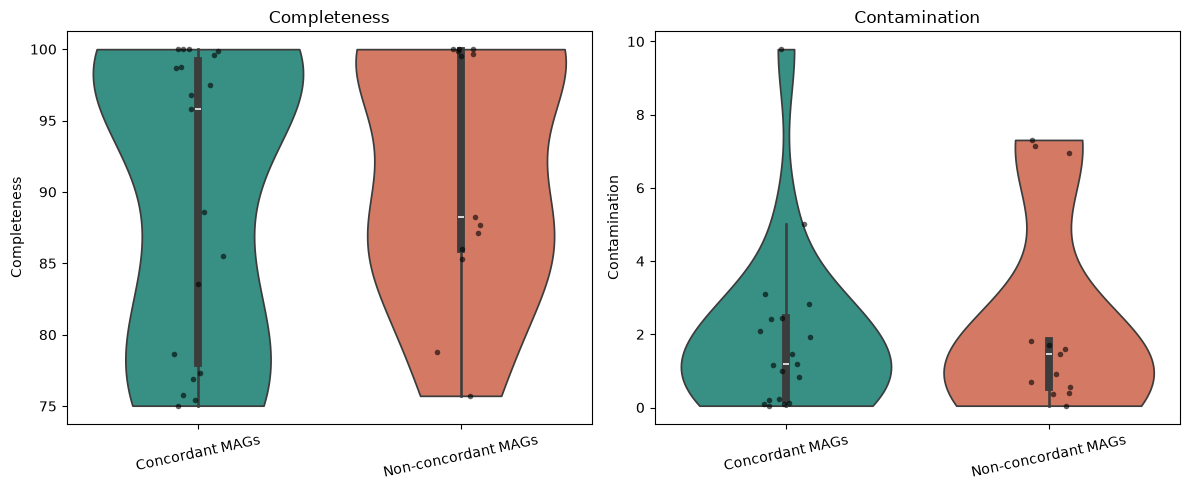

In [48]:
metrics = ["Completeness", "Contamination"]
group_order = ["Concordant MAGs", "Non-concordant MAGs"]

plot_frames = []
for group_name, frame in [
    ("Concordant MAGs", concordant_mags),
    ("Non-concordant MAGs", non_concordant_mags),
]:
    subset = frame[metrics].copy()
    for metric in metrics:
        subset[metric] = pd.to_numeric(subset[metric], errors="coerce")
    subset["Group"] = group_name
    plot_frames.append(subset)

plot_df = pd.concat(plot_frames, ignore_index=True)

palette = {
    "Concordant MAGs": "#2a9d8f",
    "Non-concordant MAGs": "#e76f51",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, metrics):
    sns.violinplot(
        data=plot_df,
        x="Group",
        y=metric,
        hue="Group",
        order=group_order,
        hue_order=group_order,
        palette=palette,
        cut=0,
        inner="box",
        legend=False,
        ax=ax,
    )
    sns.stripplot(
        data=plot_df,
        x="Group",
        y=metric,
        order=group_order,
        color="black",
        alpha=0.6,
        size=4,
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=12)

plt.tight_layout()
plt.show()